In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz

In [23]:
df = pd.read_csv("underwater_temperature.csv", encoding = 'unicode_escape')
df = df[['ID', 'Site', 'Latitude', 'Longitude', 'Date', 'Time', 'Depth', 'Temp (°C)']]

df

,ID,Site,Latitude,Longitude,Date,Time,Depth,Temp (°C)
0,1,Ilha Deserta,27.2706,48.3310,2013/02/20,11:40:02,12.0,24.448
1,2,Ilha Deserta,27.2706,48.3310,2013/02/20,12:00:03,12.0,24.448
2,3,Ilha Deserta,27.2706,48.3310,2013/02/20,12:20:04,12.0,24.545
3,4,Ilha Deserta,27.2706,48.3310,2013/02/20,12:40:05,12.0,24.448
4,5,Ilha Deserta,27.2706,48.3310,2013/02/20,13:00:06,12.0,24.351
...,...,...,...,...,...,...,...,...
408633,408634,lha do Xavier,27.6092,48.3858,2013/03/07,09:03:29,5.0,24.931
408634,408635,lha do Xavier,27.6092,48.3858,2013/03/07,09:23:29,5.0,24.931
408635,408636,lha do Xavier,27.6092,48.3858,2013/03/07,09:43:29,5.0,24.931
408636,408637,lha do Xavier,27.6092,48.3858,2013/03/07,10:03:29,5.0,24.931


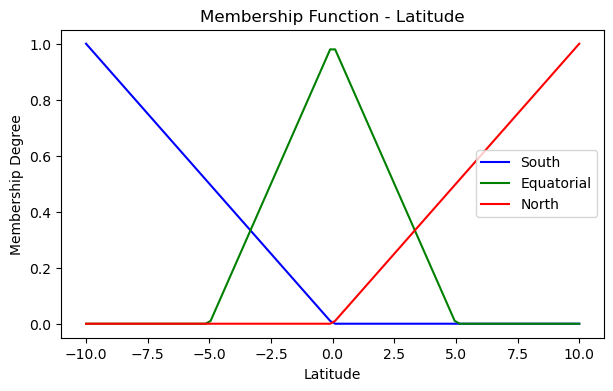

In [32]:
# berdasarkan lattitude
x_lat = np.linspace(-10, 10, 100)
lat_south = fuzz.trimf(x_lat, [-10, -10, 0])
lat_equatorial = fuzz.trimf(x_lat, [-5, 0, 5])
lat_north = fuzz.trimf(x_lat, [0, 10, 10])

plt.figure(figsize=(7,4))
plt.plot(x_lat, lat_south, 'b', label='South')
plt.plot(x_lat, lat_equatorial, 'g', label='Equatorial')
plt.plot(x_lat, lat_north, 'r', label='North')
plt.title('Membership Function - Latitude')
plt.xlabel('Latitude')
plt.ylabel('Membership Degree')
plt.legend()
plt.show()

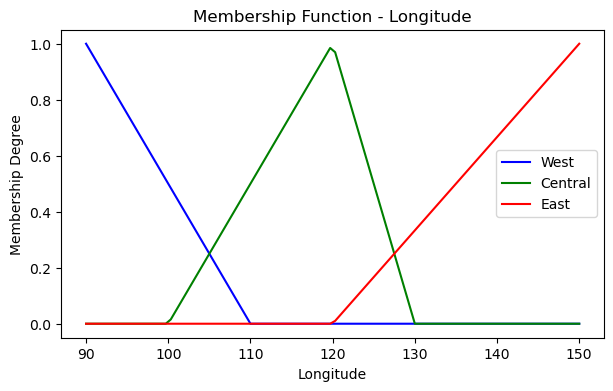

In [33]:
# berdasarkan longtitude
x_lon = np.linspace(90, 150, 100)
lon_west = fuzz.trimf(x_lon, [90, 90, 110])
lon_central = fuzz.trimf(x_lon, [100, 120, 130])
lon_east = fuzz.trimf(x_lon, [120, 150, 150])

plt.figure(figsize=(7,4))
plt.plot(x_lon, lon_west, 'b', label='West')
plt.plot(x_lon, lon_central, 'g', label='Central')
plt.plot(x_lon, lon_east, 'r', label='East')
plt.title('Membership Function - Longitude')
plt.xlabel('Longitude')
plt.ylabel('Membership Degree')
plt.legend()
plt.show()

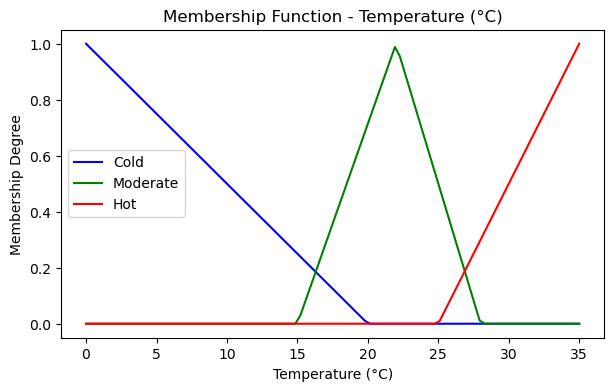

In [34]:
#berdasarkan temperatur
x_temp = np.linspace(0, 35, 100)
temp_cold = fuzz.trimf(x_temp, [0, 0, 20])
temp_moderate = fuzz.trimf(x_temp, [15, 22, 28])
temp_hot = fuzz.trimf(x_temp, [25, 35, 35])

plt.figure(figsize=(7,4))
plt.plot(x_temp, temp_cold, 'b', label='Cold')
plt.plot(x_temp, temp_moderate, 'g', label='Moderate')
plt.plot(x_temp, temp_hot, 'r', label='Hot')
plt.title('Membership Function - Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Membership Degree')
plt.legend()
plt.show()

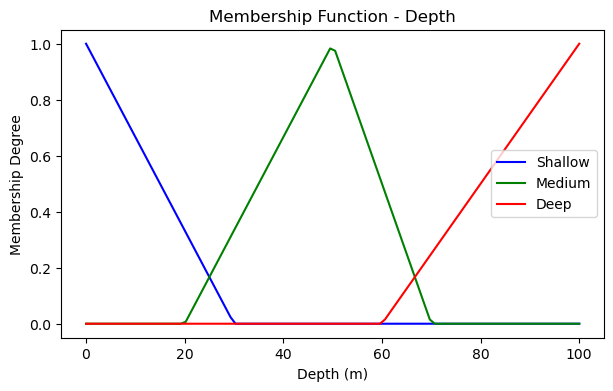

In [36]:
#berdasrakan kedalaman
x_depth = np.linspace(0, 100, 100)
depth_shallow = fuzz.trimf(x_depth, [0, 0, 30])
depth_medium = fuzz.trimf(x_depth, [20, 50, 70])
depth_deep = fuzz.trimf(x_depth, [60, 100, 100])

plt.figure(figsize=(7,4))
plt.plot(x_depth, depth_shallow, 'b', label='Shallow')
plt.plot(x_depth, depth_medium, 'g', label='Medium')
plt.plot(x_depth, depth_deep, 'r', label='Deep')
plt.title('Membership Function - Depth')
plt.xlabel('Depth (m)')
plt.ylabel('Membership Degree')
plt.legend()
plt.show()

In [40]:
#insight baru
df = pd.read_csv("underwater_temperature.csv", encoding='unicode_escape')
df = df[['ID', 'Site', 'Latitude', 'Longitude', 'Date', 'Time', 'Depth', 'Temp (°C)']]

# Buat kolom baru berdasarkan suhu
df['Temp_Category'] = pd.cut(df['Temp (°C)'],
                             bins=[0, 20, 28, 40],
                             labels=['Cold', 'Moderate', 'Hot'])

print(df.head())



   ID          Site  Latitude  Longitude        Date      Time  Depth  \
0   1  Ilha Deserta   27.2706     48.331  2013/02/20  11:40:02   12.0   
1   2  Ilha Deserta   27.2706     48.331  2013/02/20  12:00:03   12.0   
2   3  Ilha Deserta   27.2706     48.331  2013/02/20  12:20:04   12.0   
3   4  Ilha Deserta   27.2706     48.331  2013/02/20  12:40:05   12.0   
4   5  Ilha Deserta   27.2706     48.331  2013/02/20  13:00:06   12.0   

   Temp (°C) Temp_Category  
0     24.448      Moderate  
1     24.448      Moderate  
2     24.545      Moderate  
3     24.448      Moderate  
4     24.351      Moderate  


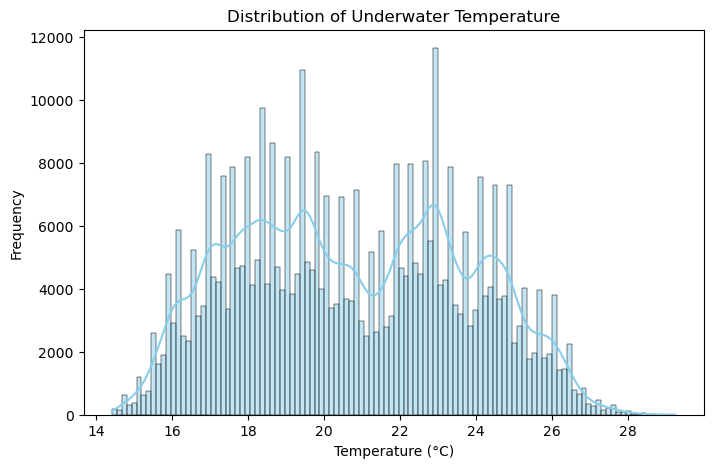

In [48]:
#distribusi suhu berdasarkan kategori
plt.figure(figsize=(8,5))
sns.histplot(df['Temp (°C)'], kde=True, color='skyblue')
plt.title('Distribution of Underwater Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

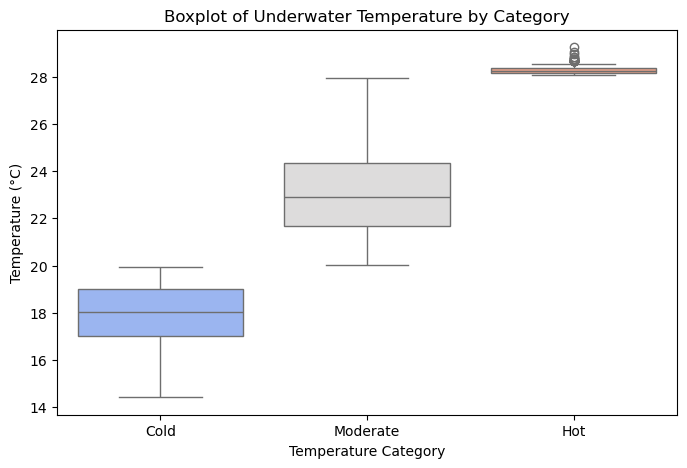

In [47]:
#boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Temp_Category', y='Temp (°C)', hue='Temp_Category',
            palette='coolwarm', legend=False)
plt.title('Boxplot of Underwater Temperature by Category')
plt.xlabel('Temperature Category')
plt.ylabel('Temperature (°C)')
plt.show()